# Logistic Regression pipeline for Dota snapshot data

Этот ноутбук — готовый шаблон под датасет вида:

- ~700k строк
- ~100 признаков
- 5 категориальных признаков — id героя Dota
- бинарная цель

Главная идея здесь не просто "обучить логрег", а сделать это **без утечек**, с **понятным preprocessing** и с **корректным замером качества**.

Я специально объясняю каждый шаг прямо в ноутбуке, чтобы по нему можно было учиться и потом спокойно адаптировать под свой датасет.

## Почему именно такой пайплайн

Для этих данных есть несколько важных особенностей:

1. **Строки — это снапшоты во времени**, а не независимые объекты.  
   Поэтому обычный random split по строкам может протащить один и тот же матч и в train, и в test. Это даёт завышенные метрики.

2. **5 колонок — категориальные id героев**.  
   Для логистической регрессии естественный выбор — `OneHotEncoder`.  
   При 127 героях это всего около `5 × 127 = 635` дополнительных бинарных признаков, что для логрега нормально.

3. **Логистическая регрессия оптимизирует log loss**, поэтому логично:
   - делать вероятности через `predict_proba`
   - подбирать гиперпараметры по `log_loss`
   - отдельно смотреть пороговые метрики (`F1`, `precision`, `recall`, `accuracy`) уже после выбора порога

4. **Большой датасет**.  
   Поэтому нужен не слишком тяжёлый, но устойчивый baseline:
   - `solver="saga"` — хорошо работает со sparse-матрицами и большими выборками
   - `penalty="l2"` — надёжный baseline, который обычно не ломается на шумных табличных данных
   - `max_iter` повышаем, потому что на больших данных дефолт может не сойтись

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


import json
from pandas.api.types import is_numeric_dtype

## Конфигурация

Здесь нужно подставить свои названия колонок.

Я специально оставляю конфиг явным, а не пытаюсь полностью угадать схему датасета: так меньше шансов тихо обучить модель "не на том".

In [2]:

DATA_PATH = Path("../full_dataset.csv")
HERO_NAMES_PATH = Path("../heroNames.json") # надо для преобразования имен героев в их id

TARGET_COL = "dead_in_1"
MATCH_ID_COL = "match_id" 
TIME_COL = "game_time"

HERO_COLS = ["hero_id", "enemy_1_name", "enemy_2_name", "enemy_3_name", "enemy_4_name", "enemy_5_name"]

RANDOM_STATE = 120
TEST_SIZE = 0.15
VAL_SIZE = 0.15

ARTIFACT_DIR = Path("artifacts/logreg")
ARTIFACT_DIR.mkdir(exist_ok=True)

## Загрузка данных

Поддерживаем как CSV, так и parquet.  
Для такого объёма данных parquet обычно удобнее и быстрее, но CSV тоже окей для шаблона.

In [3]:
def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path.resolve()}")

    suffix = path.suffix.lower()
    if suffix == ".csv":
        df = pd.read_csv(path)
    elif suffix in {".parquet", ".pq"}:
        df = pd.read_parquet(path)
    elif suffix == ".feather":
        df = pd.read_feather(path)
    else:
        raise ValueError(f"Неподдерживаемый формат: {suffix}")

    return df


df = load_data(DATA_PATH)
print(df.shape)
df.head()

(714600, 106)


,id,match_id,game_time,is_day,is_radiant,radiant_score,dire_score,hero_id,level,kills,...,item_sphere,item_manta,item_blade_mail,item_aeon_disk,item_pipe,dead_in_1,dead_in_5,dead_in_10,dead_in_15,dead_in_20
0,1,8766917279,43,1,1,0,0,86,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,8766917279,65,1,1,0,0,129,1,0,...,0,0,0,0,0,0,0,0,0,1
2,3,8766917279,68,1,1,0,0,129,1,0,...,0,0,0,0,0,0,0,0,1,1
3,4,8766917279,77,1,1,0,0,129,1,0,...,0,0,0,0,0,0,0,1,1,1
4,5,8766917279,80,1,1,0,0,129,1,0,...,0,0,0,0,0,0,1,1,1,1


## Быстрая проверка данных

Сначала убедимся, что:
- target бинарный
- есть нужные колонки
- нет совсем странных пропусков
- нет дубликатов строк

Это не формальность: очень часто проблемы качества начинаются не с модели, а с кривой разметки или дублирования.

In [5]:
missing_cols = [c for c in [TARGET_COL, MATCH_ID_COL] + HERO_COLS if c not in df.columns]

print("Missing columns:", missing_cols)

assert TARGET_COL in df.columns, f"Нет target-колонки: {TARGET_COL}"
assert MATCH_ID_COL in df.columns, f"Нет колонки для группировки матчей: {MATCH_ID_COL}"

print("Target distribution:")
print(df[TARGET_COL].value_counts(dropna=False))
print()
print("Target rate:")
print(df[TARGET_COL].mean())

dup_count = df.duplicated().sum()
print(f"Duplicates: {dup_count}")

na_share = (df.isna().mean().sort_values(ascending=False).head(15))
print("\nTop missingness:")
print(na_share)

Missing columns: []
Target distribution:
dead_in_1
0    592889
1    121711
Name: count, dtype: int64

Target rate:
0.17032045899804085
Duplicates: 0

Top missingness:
enemy_1_name     0.000067
enemy_5_name     0.000034
game_time        0.000000
is_day           0.000000
is_radiant       0.000000
radiant_score    0.000000
dire_score       0.000000
hero_id          0.000000
id               0.000000
match_id         0.000000
deaths           0.000000
assists          0.000000
last_hits        0.000000
denies           0.000000
gold             0.000000
dtype: float64


## Очистка датасета, предподготовка


In [6]:
def transform_name_to_id(df: pd.DataFrame, hero_cols: list[str]) -> pd.DataFrame:
    with open(HERO_NAMES_PATH, "r") as f:
        data = json.load(f)
    
    for col in hero_cols:
        if is_numeric_dtype(df[col]):
            continue  # уже в виде id, пропускаем
        df[col] = df[col].apply(lambda x: data.get(x, pd.NA))
        df[col] = df[col].astype("Int64")  # используем nullable integer dtype для сохранения NA

    return df

ENEMIES_NUMBER = 5
def sort_enemies(df: pd.DataFrame) -> pd.DataFrame:
    enemy_names_cols = [f"enemy_{i}_name" for i in range(1, ENEMIES_NUMBER + 1)]
    enemy_x_cols = [f"enemy_{i}_last_seen_x" for i in range(1, ENEMIES_NUMBER + 1)]
    enemy_y_cols = [f"enemy_{i}_last_seen_y" for i in range(1, ENEMIES_NUMBER + 1)]
    enemy_square_cols = [f"enemy_{i}_last_seen_sqare" for i in range(1, ENEMIES_NUMBER + 1)]
    enemy_distance_cols = [f"enemy_{i}_last_seen_distance" for i in range(1, ENEMIES_NUMBER + 1)]
    enemy_time_cols = [f"enemy_{i}_last_seen_time" for i in range(1, ENEMIES_NUMBER + 1)]

    enemy_names = df[enemy_names_cols].to_numpy()
    enemy_x = df[enemy_x_cols].to_numpy()
    enemy_y = df[enemy_y_cols].to_numpy()
    enemy_square = df[enemy_square_cols].to_numpy()
    enemy_distance = df[enemy_distance_cols].to_numpy()
    enemy_time = df[enemy_time_cols].to_numpy()

    order = np.argsort(enemy_distance, axis=1)

    sorted_enemy_names = np.take_along_axis(enemy_names, order, axis=1)
    sorted_enemy_x = np.take_along_axis(enemy_x, order, axis=1)
    sorted_enemy_y = np.take_along_axis(enemy_y, order, axis=1)
    sorted_enemy_square = np.take_along_axis(enemy_square, order, axis=1)
    sorted_enemy_distance = np.take_along_axis(enemy_distance, order, axis=1)
    sorted_enemy_time = np.take_along_axis(enemy_time, order, axis=1)

    df[enemy_names_cols] = sorted_enemy_names
    df[enemy_x_cols] = sorted_enemy_x
    df[enemy_y_cols] = sorted_enemy_y
    df[enemy_square_cols] = sorted_enemy_square
    df[enemy_distance_cols] = sorted_enemy_distance
    df[enemy_time_cols] = sorted_enemy_time

    return df


df = df.pipe(transform_name_to_id, HERO_COLS).pipe(sort_enemies).dropna()
df.shape

(714528, 106)

## Разделяем признаки

Логика такая:

- `TARGET_COL` — это цель
- `MATCH_ID_COL` и, возможно, `TIME_COL` не должны попадать в модель как обычные признаки
- героические id кодируем как categorical
- все остальные числовые признаки идут в numeric pipeline

Важно: если у вас есть какие-то ещё "технические" колонки, которые не должны обучать модель, добавьте их в `DROP_COLS`.

In [7]:
COLS_TO_DROP = [TARGET_COL, MATCH_ID_COL, "id", "slot_1_id", "slot_2_id", "slot_3_id", "slot_4_id", "slot_5_id", "dead_in_1", "dead_in_5", "dead_in_10", "dead_in_15", "dead_in_20"]

HERO_COLS_EXISTING = [c for c in HERO_COLS if c in df.columns]

feature_cols = [c for c in df.columns if c not in COLS_TO_DROP]
categorical_cols = HERO_COLS_EXISTING
numeric_cols = [c for c in feature_cols if c not in categorical_cols]


print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", categorical_cols)

Numeric cols: 88
Categorical cols: ['hero_id', 'enemy_1_name', 'enemy_2_name', 'enemy_3_name', 'enemy_4_name', 'enemy_5_name']


## Почему split нужно делать по match_id

Если строки — это снапшоты внутри матчей, то random split по строкам почти наверняка создаст leakage:

- один и тот же матч попадёт и в train, и в test
- модель увидит очень похожие состояния игры в обучении и проверке
- метрики будут заметно лучше, чем в реальном использовании

Поэтому здесь используется **group split по match_id**.

Это важнее, чем любой тонкий подбор `C` или solver: сначала надо честно разделить данные, а уже потом мерить качество.

In [8]:
def group_train_val_test_split(
    df: pd.DataFrame,
    group_col: str,
    test_size: float = 0.15,
    val_size: float = 0.15,
    random_state: int = 42,
):
    """
    Делит датасет на train/val/test так, чтобы группы не пересекались между сплитами.
    """
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(gss1.split(df, df[TARGET_COL], groups=df[group_col]))

    df_train_val = df.iloc[train_val_idx].copy()
    df_test = df.iloc[test_idx].copy()

    val_ratio_within_train_val = val_size / (1.0 - test_size)

    gss2 = GroupShuffleSplit(
        n_splits=1,
        test_size=val_ratio_within_train_val,
        random_state=random_state,
    )
    train_idx, val_idx = next(gss2.split(df_train_val, df_train_val[TARGET_COL], groups=df_train_val[group_col]))

    df_train = df_train_val.iloc[train_idx].copy()
    df_val = df_train_val.iloc[val_idx].copy()

    return df_train, df_val, df_test


df_train, df_val, df_test = group_train_val_test_split(
    df,
    group_col=MATCH_ID_COL,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(name, "unique matches:", part[MATCH_ID_COL].nunique())

Train: (527982, 106)
Val:   (93944, 106)
Test:  (92602, 106)
train unique matches: 1294
val unique matches: 278
test unique matches: 278


## Препроцессинг

### Почему именно так

**Numeric features**
- `SimpleImputer(strategy="median")` — устойчивый дефолт, если есть пропуски
- `StandardScaler` — важен для логистической регрессии, потому что она чувствительна к масштабу признаков

**Categorical hero id**
- `OneHotEncoder(handle_unknown="ignore")` — даёт честное кодирование и не падает на новых значениях в инференсе
- `handle_unknown="ignore"` особенно важен в проде: модель должна уметь спокойно обрабатывать непривычные значения
- `drop=None` — оставляем все категории. Для регуляризованной логистической регрессии это обычно нормально; регуляризация сама сглаживает избыточность

Почему не target encoding:
- здесь всего 127 героев
- one-hot получается не очень широким
- one-hot проще интерпретировать и безопаснее

Почему `solver="saga"`:
- хорошо работает со sparse-матрицами
- подходит для больших выборок
- стабильно используется для логрега на табличных данных с one-hot

In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

## Базовый выбор гиперпараметров

Для старта я беру:

- `penalty="l2"` — самый устойчивый baseline
- `C=1.0` — стандартная точка старта для регуляризации
- `max_iter=500` — потому что на больших данных дефолт может не дойти до сходимости
- `tol=1e-3` — разумный компромисс между точностью и временем обучения

### Почему не сразу сложный поиск
На 700k строк полный перебор большого грид-сета может быть дорогим.  
Поэтому сначала делаем небольшой разумный поиск по `C`, а уже потом при необходимости расширяем пространство.

In [10]:
def get_class_weight_option(y: pd.Series):
    """
    Автоматически решаем, нужен ли class_weight.
    Это не "магия", а практичный эвристический старт:
    если классы заметно несбалансированы, weighted loss часто помогает.
    """
    pos_rate = float(np.mean(y))
    minority_rate = min(pos_rate, 1.0 - pos_rate)

    # Порог можно менять. 0.35 — мягкий критерий "уже есть дисбаланс".
    use_balanced = minority_rate < 0.35

    return "balanced" if use_balanced else None, pos_rate, minority_rate


X_train = df_train[feature_cols]
y_train = df_train[TARGET_COL].astype(int)

X_val = df_val[feature_cols]
y_val = df_val[TARGET_COL].astype(int)

X_test = df_test[feature_cols]
y_test = df_test[TARGET_COL].astype(int)

class_weight, pos_rate, minority_rate = get_class_weight_option(y_train)
print("Positive rate in train:", pos_rate)
print("Minority rate in train:", minority_rate)
print("class_weight:", class_weight)

Positive rate in train: 0.17026716819891588
Minority rate in train: 0.17026716819891588
class_weight: balanced


## Подбор `C` по validation

Мы выбираем `C` по `log_loss`, потому что:

- именно log loss соответствует оптимизируемой цели логистической регрессии
- метрика учитывает качество вероятностей, а не только правильность класса
- это особенно важно, если потом вы будете использовать вероятности в downstream-логике

Дополнительно смотрим `ROC-AUC` и `PR-AUC`, чтобы видеть картину шире.

In [10]:
def make_model(C: float, class_weight=None) -> Pipeline:
    clf = LogisticRegression(
        solver="saga",
        C=C,
        class_weight=class_weight,
        max_iter=500,
        tol=1e-3,
        random_state=RANDOM_STATE,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("clf", clf),
        ]
    )


def evaluate_probabilities(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    out = {
        "logloss": log_loss(y_true, y_proba, labels=[0, 1]),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier": brier_score_loss(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    return out


candidate_C = [0.03, 0.1, 0.3, 1.0, 3.0]
search_results = []

for C in candidate_C:
    model = make_model(C=C, class_weight=class_weight)
    model.fit(X_train, y_train)

    val_proba = model.predict_proba(X_val)[:, 1]
    metrics = evaluate_probabilities(y_val, val_proba, threshold=0.5)
    search_results.append({"C": C, **metrics})

search_df = pd.DataFrame(search_results).sort_values(["logloss", "roc_auc"], ascending=[True, False])
search_df

,C,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1
4,3.00,0.649428,0.669436,0.266902,0.232371,0.567764,0.241051,0.712843,0.360273
3,1.00,0.649432,0.669446,0.266904,0.232372,0.567711,0.241036,0.712905,0.360265
2,0.30,0.649446,0.669479,0.266912,0.232375,0.567487,0.240842,0.712406,0.359985
1,0.10,0.649484,0.669565,0.266941,0.232383,0.567402,0.240802,0.712406,0.359940
0,0.03,0.649605,0.669820,0.267032,0.232409,0.566848,0.240822,0.714027,0.360169


### Как выбрать лучший `C`

По умолчанию выбираем по минимальному `logloss`.

Это хороший выбор, потому что:
- логрег сам минимизирует логлосс
- мы хотим хорошую вероятностную модель, а не просто "угадывание класса"
- `C` управляет силой регуляризации:
  - маленький `C` → сильнее регуляризация → модель проще
  - большой `C` → слабее регуляризация → модель гибче, но риск переобучения выше

На таких данных слишком большой `C` часто даёт чуть лучше train и хуже val, поэтому логично смотреть именно validation.

In [11]:
best_row = search_df.iloc[0]
best_C = float(best_row["C"])
print("Best C:", best_C)

best_model = make_model(C=best_C, class_weight=class_weight)
best_model.fit(X_train, y_train)

val_proba = best_model.predict_proba(X_val)[:, 1]
val_metrics = evaluate_probabilities(y_val, val_proba, threshold=0.5)
val_metrics

Best C: 3.0


{'logloss': 0.6494284087413972,
 'roc_auc': 0.6694363985420512,
 'pr_auc': 0.2669017893022839,
 'brier': 0.23237130138503453,
 'accuracy': 0.5677637741633313,
 'precision': 0.24105072311000547,
 'recall': 0.7128428927680798,
 'f1': 0.36027349781012696}

## Подбор порога по validation

Вероятности — это одно, а финальное решение `0/1` — другое.

Порог 0.5 не всегда оптимален, особенно если:
- классы несбалансированы
- false positive и false negative стоят по-разному
- задача оптимизируется не под accuracy

Поэтому порог удобно выбрать на validation, например по максимуму `F1`.

In [12]:
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)

# thresholds на 1 короче, чем precision/recall
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
best_threshold_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_threshold_idx])

print("Best threshold by F1 on validation:", best_threshold)
print("Validation F1 at best threshold:", float(f1_scores[best_threshold_idx]))

Best threshold by F1 on validation: 0.5203014429871553
Validation F1 at best threshold: 0.36214924748394506


## Финальная оценка на test

Тест мы трогаем только один раз.  
Все решения — выбор `C`, решение про `class_weight`, выбор порога — уже должны быть определены до test.

Это важно, иначе мы начинаем "подгонять" метрики под test и теряем честность оценки.

In [13]:
test_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics_05 = evaluate_probabilities(y_test, test_proba, threshold=0.5)
test_metrics_best_thr = evaluate_probabilities(y_test, test_proba, threshold=best_threshold)

pd.DataFrame(
    [
        {"split": "test @ 0.5", **test_metrics_05},
        {"split": f"test @ {best_threshold:.4f}", **test_metrics_best_thr},
    ]
)

,split,logloss,roc_auc,pr_auc,brier,accuracy,precision,recall,f1
0,test @ 0.5,0.649152,0.668971,0.264175,0.232079,0.568951,0.240360,0.708796,0.358985
1,test @ 0.5203,0.649152,0.668971,0.264175,0.232079,0.612006,0.250136,0.639926,0.359680


## ROC и PR-кривые

ROC-AUC хорошо показывает ранжирование объектов,  
PR-AUC обычно полезнее, если положительный класс редкий.

На несбалансированных данных PR-AUC часто даёт более честное ощущение качества, чем accuracy.

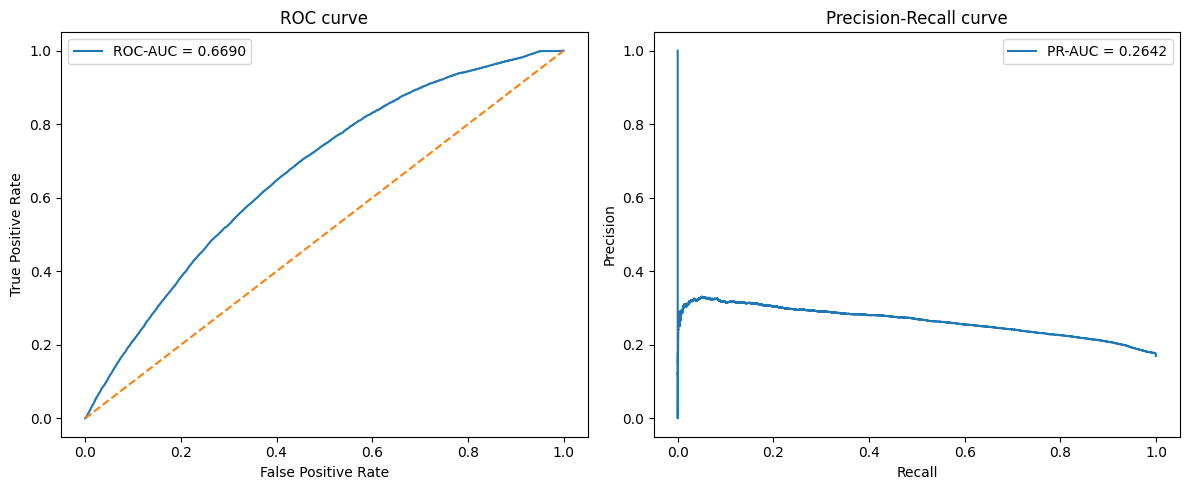

In [14]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_proba):.4f}")
ax[0].plot([0, 1], [0, 1], linestyle="--")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC curve")
ax[0].legend()

ax[1].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, test_proba):.4f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve")
ax[1].legend()

plt.tight_layout()
plt.show()

## Матрица ошибок

Это уже threshold-dependent метрика, поэтому здесь используем порог, который выбрали по validation.

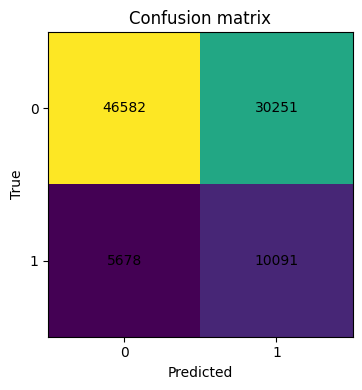

In [15]:
test_pred = (test_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
ax.set_title("Confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## Интерпретация коэффициентов

У логистической регрессии есть приятный бонус: коэффициенты можно читать.

После one-hot энкодинга можно посмотреть:
- какие признаки сильнее всего двигают вероятность вверх
- какие — вниз

Это полезно для sanity check: модель может быть сильной, но с явно странной логикой.

In [16]:
# Получаем имена признаков после preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coef = best_model.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef),
    }
).sort_values("abs_coef", ascending=False)

display(coef_df.head(20))
print("\nTop positive coefficients:")
display(coef_df.sort_values("coef", ascending=False).head(20)[["feature", "coef"]])

print("\nTop negative coefficients:")
display(coef_df.sort_values("coef", ascending=True).head(20)[["feature", "coef"]])

,feature,coef,abs_coef
24,num__magical_resistance,1.111801,1.111801
47,num__enemy_1_last_seen_y,1.067192,1.067192
67,num__enemy_5_last_seen_y,0.671194,0.671194
58,num__enemy_3_last_seen_sqare,-0.656941,0.656941
57,num__enemy_3_last_seen_y,0.637368,0.637368
52,num__enemy_2_last_seen_y,0.633740,0.633740
48,num__enemy_1_last_seen_sqare,-0.630239,0.630239
63,num__enemy_4_last_seen_sqare,-0.623783,0.623783
53,num__enemy_2_last_seen_sqare,-0.617910,0.617910
22,num__intellect,-0.615826,0.615826



Top positive coefficients:


,feature,coef
24,num__magical_resistance,1.111801
47,num__enemy_1_last_seen_y,1.067192
67,num__enemy_5_last_seen_y,0.671194
57,num__enemy_3_last_seen_y,0.637368
52,num__enemy_2_last_seen_y,0.633740
62,num__enemy_4_last_seen_y,0.583906
44,num__nearest_ally_tower_distance,0.516210
46,num__enemy_1_last_seen_x,0.402213
245,cat__enemy_1_name_32,0.330482
160,cat__hero_id_74,0.292556



Top negative coefficients:


,feature,coef
58,num__enemy_3_last_seen_sqare,-0.656941
48,num__enemy_1_last_seen_sqare,-0.630239
63,num__enemy_4_last_seen_sqare,-0.623783
53,num__enemy_2_last_seen_sqare,-0.617910
22,num__intellect,-0.615826
68,num__enemy_5_last_seen_sqare,-0.595672
49,num__enemy_1_last_seen_distance,-0.551090
335,cat__enemy_1_name_131,-0.400108
300,cat__enemy_1_name_87,-0.358604
195,cat__hero_id_109,-0.345003


## Сохранение модели

Сохраняем не только сам классификатор, а **весь pipeline**:

- preprocessing
- encoding
- scaler
- model

Это критично, потому что в инференсе нужно повторить ровно тот же путь преобразования признаков.

In [17]:
s = TARGET_COL[-1] + "s"
    
artifact_path = ARTIFACT_DIR / f"dota_logreg_pipeline_{s}.joblib"
joblib.dump(best_model, artifact_path)

print(f"Saved to: {artifact_path.resolve()}")

Saved to: /home/kandratt/Desktop/ml-in-dota/data/models/artifacts/dota_logreg_pipeline_1s.joblib


In [18]:
s

'1s'